# Gold Recovery Prediction

### Libraries loading (Cargar las librerías)

In [2]:
# Data manipulation
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    f1_score,
    mean_squared_error
)

# Utilities
from sklearn.utils import shuffle


### Data loading (cargar los datos)

In [3]:
#Crea un objeto Path que representa el directorio actual, .resolve() convierte esa ruta en una ruta absoluta completa
BASE_DIR = Path().resolve()
DATA_DIR = BASE_DIR / "data" 

#Define las rutas de los archivos
train_path = DATA_DIR / "gold_recovery_train.csv"
test_path = DATA_DIR / "gold_recovery_test.csv"
full_path = DATA_DIR / "gold_recovery_full.csv" 

# Cargar datasets
gold_recovery_train = pd.read_csv(train_path)
gold_recovery_test = pd.read_csv(test_path)
gold_recovery_full = pd.read_csv(full_path)


### Exploratory Data Analysis (Análisis exploratorio de datos)

In [4]:
datasets = {
    "Train": gold_recovery_train,
    "Test": gold_recovery_test,
    "Full": gold_recovery_full
}

#Cálculo de dimensiones de los datasets
print("Dimensiones de los datasets:\n")

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

print("\nValores ausentes:\n")

#Cálculo de valores ausentes en cada dataset
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    total_values = df.size
    missing_percent = (total_missing / total_values) * 100
    
    print(f"{name} - Total valores ausentes: {total_missing} ({missing_percent:.2f}%)")
    
#Cálculo de valores ausentes por cada columna de cada dataset
for name, df in datasets.items():
    print(f"\nAnálisis de valores ausentes - {name}")
    
    missing_df = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_percent": (df.isnull().mean() * 100).round(2)
    }).sort_values(by="missing_percent", ascending=False)
    
    print(missing_df.head(10))


Dimensiones de los datasets:

Train: (16860, 87)
Test: (5856, 53)
Full: (22716, 87)

Valores ausentes:

Train - Total valores ausentes: 30320 (2.07%)
Test - Total valores ausentes: 2360 (0.76%)
Full - Total valores ausentes: 36587 (1.85%)

Análisis de valores ausentes - Train
                                    missing_count  missing_percent
rougher.output.recovery                      2573            15.26
rougher.output.tail_ag                       2250            13.35
rougher.output.tail_au                       2249            13.34
rougher.output.tail_sol                      2249            13.34
secondary_cleaner.output.tail_sol            1986            11.78
rougher.input.floatbank11_xanthate           1904            11.29
final.output.recovery                        1521             9.02
primary_cleaner.input.sulfate                1307             7.75
primary_cleaner.input.depressant             1262             7.49
rougher.calculation.au_pb_ratio              1242    

In [5]:
# Identificar las columnas necesarias, aquellas relacionadas conrougher

rougher_cols = [col for col in gold_recovery_train.columns if 'rougher' in col]
print('Columnas rougher disponibles:')
for col in rougher_cols:
    print(f" - {col}")

Columnas rougher disponibles:
 - rougher.calculation.sulfate_to_au_concentrate
 - rougher.calculation.floatbank10_sulfate_to_au_feed
 - rougher.calculation.floatbank11_sulfate_to_au_feed
 - rougher.calculation.au_pb_ratio
 - rougher.input.feed_ag
 - rougher.input.feed_pb
 - rougher.input.feed_rate
 - rougher.input.feed_size
 - rougher.input.feed_sol
 - rougher.input.feed_au
 - rougher.input.floatbank10_sulfate
 - rougher.input.floatbank10_xanthate
 - rougher.input.floatbank11_sulfate
 - rougher.input.floatbank11_xanthate
 - rougher.output.concentrate_ag
 - rougher.output.concentrate_pb
 - rougher.output.concentrate_sol
 - rougher.output.concentrate_au
 - rougher.output.recovery
 - rougher.output.tail_ag
 - rougher.output.tail_pb
 - rougher.output.tail_sol
 - rougher.output.tail_au
 - rougher.state.floatbank10_a_air
 - rougher.state.floatbank10_a_level
 - rougher.state.floatbank10_b_air
 - rougher.state.floatbank10_b_level
 - rougher.state.floatbank10_c_air
 - rougher.state.floatbank10_

### Data Preprocessing (Preprocesamiento de datos)

In [6]:
# Realizar el cálculo de la característica rougher.output.recovery de forma manual

#C: concentración de la sustancia en el concentrado
C = gold_recovery_train['rougher.output.concentrate_au']

#F: concentración de la sustancia en la alimentación(feed)
F = gold_recovery_train['rougher.input.feed_au']

#T: concentración de la sustancia en las colas (tails)
T = gold_recovery_train['rougher.output.tail_au']

#Calcular la recuperación
recovery_calculated = (C * (F - T)/(F * (C - T))) * 100
print(f"Recovery calculada: {recovery_calculated.head().values}")

Recovery calculada: [87.10776293 86.84326051 86.84230826 87.22642953 86.68879414]


In [7]:
# Comparar los valores calculados y los valores originales

tolerance = 0.01

close_match = abs(recovery_calculated - gold_recovery_train['rougher.output.recovery']) < tolerance
print(f'Valores similares (±{tolerance}): {close_match.sum()} de {len(close_match)}')

# Calcular el MAE
mae = abs(recovery_calculated - gold_recovery_train['rougher.output.recovery']).mean()
print(f"Error Absoluto Medio: {mae}")

Valores similares (±0.01): 14287 de 16860
Error Absoluto Medio: 9.303415616264301e-15


De acuerdo con los datos calculados, se observa que 14287 datos de 16860 (aproximadamente el 84.7%) se encuentran dentro de un intervalo del ±10%, dejando algunos datos fuera por posibles causas como la forma en que se tomaron los datos, la precisión del análisis, la precisión de los instrumentos, incertidumbre de los instrumentos, error al tomar las medidas, etc.

Por otro lado, se observa que el Error Absoluto Medio es un valor muy pequeño, lo cual aporta información sobre que los datos calculados y los datos originales se encuentran muy cercanos entre ellos. 

##### 1.3. Analiza las características no disponibles en el conjunto de prueba. ¿Cuáles son estos parámetros? ¿Cuál es su tipo?

In [8]:
# Revisar qué columnas faltan en test vs train
train_cols = set(gold_recovery_train.columns)
test_cols = set(gold_recovery_test.columns)
missing_in_test = train_cols - test_cols

print(f"Columnas que están en train pero NO en test: {len(missing_in_test)}")
print("Columnas faltantes:")
print(list(missing_in_test)[:])

Columnas que están en train pero NO en test: 34
Columnas faltantes:
['secondary_cleaner.output.tail_ag', 'primary_cleaner.output.concentrate_sol', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.tail_au', 'rougher.output.concentrate_sol', 'primary_cleaner.output.tail_sol', 'final.output.concentrate_sol', 'secondary_cleaner.output.tail_pb', 'rougher.output.tail_pb', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'primary_cleaner.output.concentrate_pb', 'rougher.calculation.sulfate_to_au_concentrate', 'final.output.recovery', 'rougher.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.tail_ag', 'rougher.output.tail_sol', 'primary_cleaner.output.tail_ag', 'final.output.tail_sol', 'final.output.concentrate_ag', 'final.output.tail_pb', 'secondary_cleaner.output.tail_au', 'rougher.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_au',

Se observa que las columnas faltantes en el dataset de prueba (test) probablemente sean las variables objetivo, lo cual explicaría el porqué se encuentran en el dataset de entrenamiento pero no en el de prueba.

##### 1.4. Realiza el preprocesamiento de datos.

In [9]:
# Mostrar solo columnas con valores ausentes y su porcentaje para el conjunto de entrenamiento:

missing_train = gold_recovery_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_percentage = (missing_train / len(gold_recovery_train)) * 100

print("Top 15 columnas con más valores ausentes:")
for i, (col, count) in enumerate(missing_train.head(15).items()):
    print(f"{i+1}. {col}: {count} ({missing_percentage[col]:.2f}%)")

Top 15 columnas con más valores ausentes:
1. rougher.output.recovery: 2573 (15.26%)
2. rougher.output.tail_ag: 2250 (13.35%)
3. rougher.output.tail_au: 2249 (13.34%)
4. rougher.output.tail_sol: 2249 (13.34%)
5. secondary_cleaner.output.tail_sol: 1986 (11.78%)
6. rougher.input.floatbank11_xanthate: 1904 (11.29%)
7. final.output.recovery: 1521 (9.02%)
8. primary_cleaner.input.sulfate: 1307 (7.75%)
9. primary_cleaner.input.depressant: 1262 (7.49%)
10. rougher.calculation.au_pb_ratio: 1242 (7.37%)
11. rougher.input.floatbank10_sulfate: 1044 (6.19%)
12. primary_cleaner.input.xanthate: 985 (5.84%)
13. primary_cleaner.output.concentrate_sol: 636 (3.77%)
14. rougher.input.floatbank11_sulfate: 623 (3.70%)
15. rougher.state.floatbank10_e_air: 603 (3.58%)


Se observa que las principales columnas con valores ausentes son las columnas que contienen variables objetivos como recovery, tail y outputs.

In [10]:
# Mostrar solo columnas con valores ausentes y su porcentaje para el conjunto de prueba:
missing_test = gold_recovery_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
missing_percentage_test = (missing_test / len(gold_recovery_test)) * 100

print("Top 15 columnas con más valores ausentes:")
for i, (col, count) in enumerate(missing_test.head(15).items()):
    print(f"{i+1}. {col}: {count} ({missing_percentage_test[col]:.2f}%)")

Top 15 columnas con más valores ausentes:
1. rougher.input.floatbank11_xanthate: 353 (6.03%)
2. primary_cleaner.input.sulfate: 302 (5.16%)
3. primary_cleaner.input.depressant: 284 (4.85%)
4. rougher.input.floatbank10_sulfate: 257 (4.39%)
5. primary_cleaner.input.xanthate: 166 (2.83%)
6. rougher.input.floatbank10_xanthate: 123 (2.10%)
7. rougher.input.feed_sol: 67 (1.14%)
8. rougher.input.floatbank11_sulfate: 55 (0.94%)
9. rougher.input.feed_rate: 40 (0.68%)
10. secondary_cleaner.state.floatbank3_a_air: 34 (0.58%)
11. secondary_cleaner.state.floatbank2_b_air: 23 (0.39%)
12. rougher.input.feed_size: 22 (0.38%)
13. secondary_cleaner.state.floatbank2_a_air: 20 (0.34%)
14. rougher.state.floatbank10_f_air: 17 (0.29%)
15. rougher.state.floatbank10_c_air: 17 (0.29%)


Se observa que las principales columnas con valorea ausentes son variables de proceso como sulfate, xanthate, depressant.

Análisis de patrones para rougher.output.recovery:
Total valores ausentes: 2573


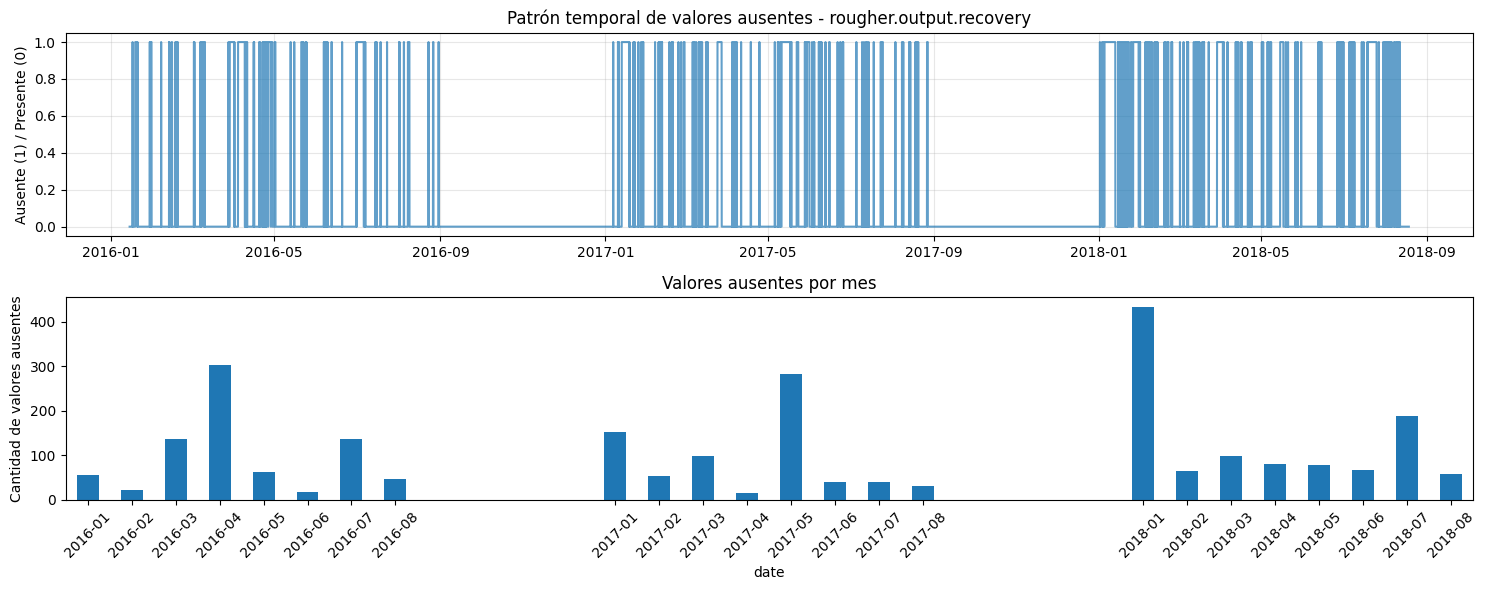

In [11]:
# Crear visualización para observar valores ausentes
# Convertir la columna date a datetime
gold_recovery_train['date'] = pd.to_datetime(gold_recovery_train['date'])

# Analizar patrones temporales de valores ausentes
column_to_analyze = 'rougher.output.recovery'  # 15.26% ausente

# Crear una serie que indique dónde hay valores ausentes
missing_pattern = gold_recovery_train[column_to_analyze].isnull()

print(f"Análisis de patrones para {column_to_analyze}:")
print(f"Total valores ausentes: {missing_pattern.sum()}")

# Crear una visualización temporal de valores ausentes
plt.figure(figsize=(15, 6))

# Crear una serie temporal que muestre valores ausentes (1) y presentes (0)
missing_timeline = gold_recovery_train[column_to_analyze].isnull().astype(int)

# Gráfico de línea temporal
plt.subplot(2, 1, 1)
plt.plot(gold_recovery_train['date'], missing_timeline, alpha=0.7)
plt.title(f'Patrón temporal de valores ausentes - {column_to_analyze}')
plt.ylabel('Ausente (1) / Presente (0)')
plt.grid(True, alpha=0.3)

# Histograma por mes para ver distribución
plt.subplot(2, 1, 2)
missing_by_month = gold_recovery_train[missing_pattern].groupby(gold_recovery_train['date'].dt.to_period('M')).size()
missing_by_month.plot(kind='bar')
plt.title('Valores ausentes por mes')
plt.ylabel('Cantidad de valores ausentes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Images/Patrón_temporal_de_valores_ausentes.png')
plt.savefig('Images/Valores_ausentes_por_mes')
plt.show()

In [12]:
# Analizar los períodos con más detalle
print("Análisis detallado de períodos con valores ausentes:")

# 1. Valores ausentes por día
missing_by_day = gold_recovery_train[missing_pattern].groupby(gold_recovery_train['date'].dt.date).size()
print(f"\nDías con más valores ausentes:")
print(missing_by_day.sort_values(ascending=False).head(10))

# 2. Valores ausentes por hora del día
missing_by_hour = gold_recovery_train[missing_pattern].groupby(gold_recovery_train['date'].dt.hour).size()
print(f"\nValores ausentes por hora del día:")
print(missing_by_hour)

# 3. Buscar secuencias consecutivas de valores ausentes
consecutive_missing = []
current_streak = 0
for is_missing in missing_pattern:
    if is_missing:
        current_streak += 1
    else:
        if current_streak > 0:
            consecutive_missing.append(current_streak)
        current_streak = 0

if consecutive_missing:
    print(f"\nSecuencias consecutivas de valores ausentes:")
    print(f"Secuencia más larga: {max(consecutive_missing)} horas")
    print(f"Promedio de secuencia: {sum(consecutive_missing)/len(consecutive_missing):.1f} horas")

Análisis detallado de períodos con valores ausentes:

Días con más valores ausentes:
date
2018-07-20    24
2016-04-08    24
2016-04-07    24
2016-04-05    24
2016-04-06    24
2016-03-31    24
2016-03-30    24
2018-01-27    24
2018-01-28    24
2018-01-29    24
dtype: int64

Valores ausentes por hora del día:
date
0      92
1      99
2     103
3     105
4     102
5     103
6     102
7      99
8     109
9     100
10    113
11    116
12    121
13    123
14    122
15    116
16    111
17    106
18    109
19    102
20    107
21    108
22    107
23     98
dtype: int64

Secuencias consecutivas de valores ausentes:
Secuencia más larga: 194 horas
Promedio de secuencia: 8.6 horas


De acuerdo con el análisis de esta variable, se observa que los datos se comportan en forma de patrones temporales, por lo que se opta por no eliminar filas con datos ausentes para no perder información valiosa de ciertos momentos del proceso y evitar afectar el análisis de tendencias y patrones. En vez de eliminar filas con valores ausentes, se optó por rellenar los valores ausentes usando una interpolación lineal pues la información del projecto menciona que los parámetros cercanos en el tiempo suelen ser similares.

In [13]:
# Implementar la imputación de datos usando la interpolación lineal

def impute_temporal_data(df, columns_to_impute):
    """
    Imputa valores ausentes usando interpolación temporal
    """
    df_imputed = df.copy()
    df_imputed = df_imputed.set_index('date')
    
    for column in columns_to_impute:
        # Interpolación lineal basada en tiempo
        df_imputed[column] = df_imputed[column].interpolate(method='time')
        
        # Para valores ausentes al inicio/final, usar forward/backward fill
        df_imputed[column] = df_imputed[column].ffill().bfill()
        #El método forward fill (ffill) toma el último valor válido disponible y lo "propaga hacia adelante" para rellenar los valores faltantes, se usa cuando el proceso industrial tiende a mantener condiciones estables hasta que hay un cambio
        #El método backward fill (bfill) toma el siguiente valor válido disponible y lo "propaga hacia atrás" para rellenar los valores faltantes, se usa cuando sabes que un valor futuro es representativo del período anterior
    return df_imputed

# Identificar columnas con valores ausentes
columns_with_missing = gold_recovery_train.columns[gold_recovery_train.isnull().any()].tolist()
#El método .any() devuelve True si al menos uno de los valores es True, devuelve False si todos son False
print(f"Columnas a imputar en el conjunto de entrenamiento: {len(columns_with_missing)}")

Columnas a imputar en el conjunto de entrenamiento: 85


In [14]:
#Rellenar valores ausentes usando la función impute_temporal_data en el conjunto de entrenamiento

gold_recovery_train_imputed = impute_temporal_data(gold_recovery_train, columns_with_missing)

In [15]:
# Identificar columnas con valores ausentes en el conjunto de prueba
columns_with_missing_test = gold_recovery_test.columns[gold_recovery_test.isnull().any()].tolist()
print(f"Columnas a imputar en el conjunto de prueba: {len(columns_with_missing_test)}")

#Rellenar valores ausentes usando la función impute_temporal_data en el conjunto de prueba
gold_recovery_test['date'] = pd.to_datetime(gold_recovery_test['date'])
gold_recovery_test_imputed = impute_temporal_data(gold_recovery_test, columns_with_missing_test)

Columnas a imputar en el conjunto de prueba: 51


In [16]:
# Identificar columnas con valores ausentes en el conjunto de datos completo
columns_with_missing_full = gold_recovery_full.columns[gold_recovery_full.isnull().any()].tolist()
print(f"Columnas a imputar en el conjunto completo: {len(columns_with_missing_test)}")

#Rellenar valores ausentes usando la función impute_temporal_data en el conjunto completo
gold_recovery_full['date'] = pd.to_datetime(gold_recovery_full['date'])
gold_recovery_full_imputed = impute_temporal_data(gold_recovery_full, columns_with_missing_full)


Columnas a imputar en el conjunto completo: 51


In [17]:
# Verificar que no quedan valores ausentes
print("Valores ausentes después de imputación:")
print(f"Train: {gold_recovery_train_imputed.isnull().sum().sum()}")
print(f"Test: {gold_recovery_test_imputed.isnull().sum().sum()}")

Valores ausentes después de imputación:
Train: 0
Test: 0


### Data Analysis (Análisis de datos)

#### 2.1. Observa cómo cambia la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación¶

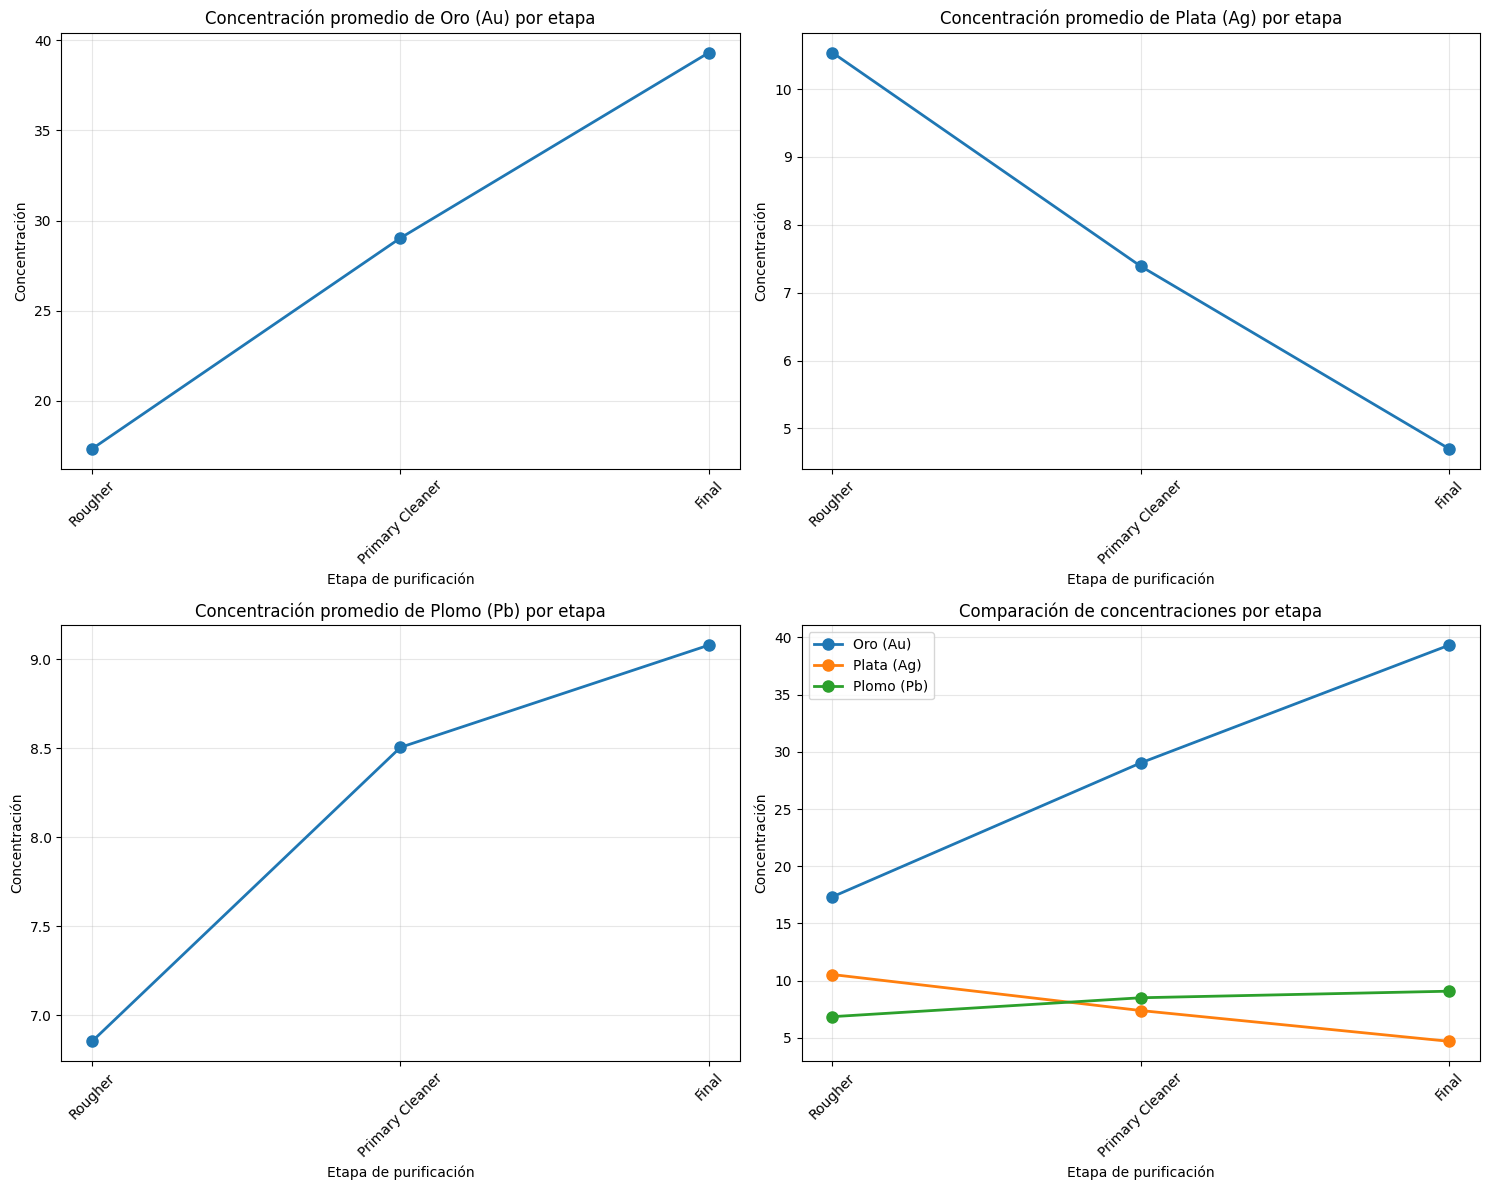

In [22]:
# Crear visualización de concentraciones de metales por etapa
plt.figure(figsize=(15, 12))

# Definir las etapas y metales
stages = ['rougher', 'primary_cleaner', 'secondary_cleaner', 'final']
metals = ['au', 'ag', 'pb']
metal_names = {'au': 'Oro (Au)', 'ag': 'Plata (Ag)', 'pb': 'Plomo (Pb)'}

# Crear subgráficos para cada metal
for i, metal in enumerate(metals):
    plt.subplot(2, 2, i+1)
    #.subplot() divide la "hoja" completa en secciones más pequeñas y pone un grafico diferente en cada sección
    
    concentrations = []
    stage_labels = []
    
    for stage in stages:
        # Buscar columnas de concentrado para cada etapa
        concentrate_col = f'{stage}.output.concentrate_{metal}'
        if concentrate_col in gold_recovery_train_imputed.columns:
            concentrations.append(gold_recovery_train_imputed[concentrate_col].mean())
            stage_labels.append(stage.replace('_', ' ').title())
    
    # Crear gráfico de línea
    plt.plot(stage_labels, concentrations, marker='o', linewidth=2, markersize=8)
    plt.title(f'Concentración promedio de {metal_names[metal]} por etapa')
    plt.xlabel('Etapa de purificación')
    plt.ylabel('Concentración')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

# Gráfico combinado
plt.subplot(2, 2, 4)
for metal in metals:
    concentrations = []
    stage_labels = []
    
    for stage in stages:
        concentrate_col = f'{stage}.output.concentrate_{metal}'
        if concentrate_col in gold_recovery_train_imputed.columns:
            concentrations.append(gold_recovery_train_imputed[concentrate_col].mean())
            stage_labels.append(stage.replace('_', ' ').title())
    
    plt.plot(stage_labels, concentrations, marker='o', linewidth=2, 
             markersize=8, label=metal_names[metal])

plt.title('Comparación de concentraciones por etapa')
plt.xlabel('Etapa de purificación')
plt.ylabel('Concentración')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Images/Comparación_de_concentraciones_por_etapa')
plt.show()

De acuerdo con los gráficos, se observa que la concentración de oro aumenta en cada una de las etapas del proceso, lo cual es lógico y es lo esperado, mientras que la plata disminuye conforme pasan las etapas, es decir, la relación de concentración entre el oro y la plata son inversamente proporcionales.

Por otro lado, se observa que las concentraciones de plomo aumentan de forma no considerable en comparación de la concentración de oro, este último metal supera por el doble la concentración del plomo en la etapa final del proceso.

#### 2.2. Compara las distribuciones del tamaño de las partículas de la alimentación en el conjunto de entrenamiento y en el conjunto de prueba. Si las distribuciones varían significativamente, la evaluación del modelo no será correcta

In [19]:
# Buscar las columnas objetivo en el conjunto de prueba

feed_size_cols_test = [col for col in gold_recovery_test.columns if 'feed' in col and 'size' in col]
print('Columnas disponibles en el conjunto de prueba:')
for col in feed_size_cols_test:
    print(f" - {col}")

Columnas disponibles en el conjunto de prueba:
 - primary_cleaner.input.feed_size
 - rougher.input.feed_size


In [20]:
# Buscar las columnas objetivo en el conjunto de entrenamiento

feed_size_cols_train = [col for col in gold_recovery_train.columns if 'feed' in col and 'size' in col]
print('Columnas disponibles en el conjunto de entrenamiento:')
for col in feed_size_cols_train:
    print(f" - {col}")

Columnas disponibles en el conjunto de entrenamiento:
 - primary_cleaner.input.feed_size
 - rougher.input.feed_size


In [21]:
# Comparar estadísticas descriptivas
print("ROUGHER FEED SIZE")
print("Entrenamiento:")
print(gold_recovery_train_imputed['rougher.input.feed_size'].describe())
print("\nPrueba:")
print(gold_recovery_test_imputed['rougher.input.feed_size'].describe())

print("\nPRIMARY CLEANER FEED SIZE")
print("Entrenamiento:")
print(gold_recovery_train_imputed['primary_cleaner.input.feed_size'].describe())
print("\nPrueba:")
print(gold_recovery_test_imputed['primary_cleaner.input.feed_size'].describe())

ROUGHER FEED SIZE
Entrenamiento:
count    16860.000000
mean        59.152776
std         26.131277
min          9.659576
25%         47.540138
50%         54.029671
75%         65.272775
max        484.967466
Name: rougher.input.feed_size, dtype: float64

Prueba:
count    5856.000000
mean       55.886800
std        22.704970
min         0.046369
25%        43.865121
50%        49.964796
75%        61.615634
max       477.445473
Name: rougher.input.feed_size, dtype: float64

PRIMARY CLEANER FEED SIZE
Entrenamiento:
count    16860.000000
mean         7.297285
std          0.619166
min          1.080000
25%          6.940000
50%          7.285000
75%          7.700000
max         10.470000
Name: primary_cleaner.input.feed_size, dtype: float64

Prueba:
count    5856.000000
mean        7.264651
std         0.611526
min         5.650000
25%         6.885625
50%         7.259333
75%         7.650000
max        15.500000
Name: primary_cleaner.input.feed_size, dtype: float64


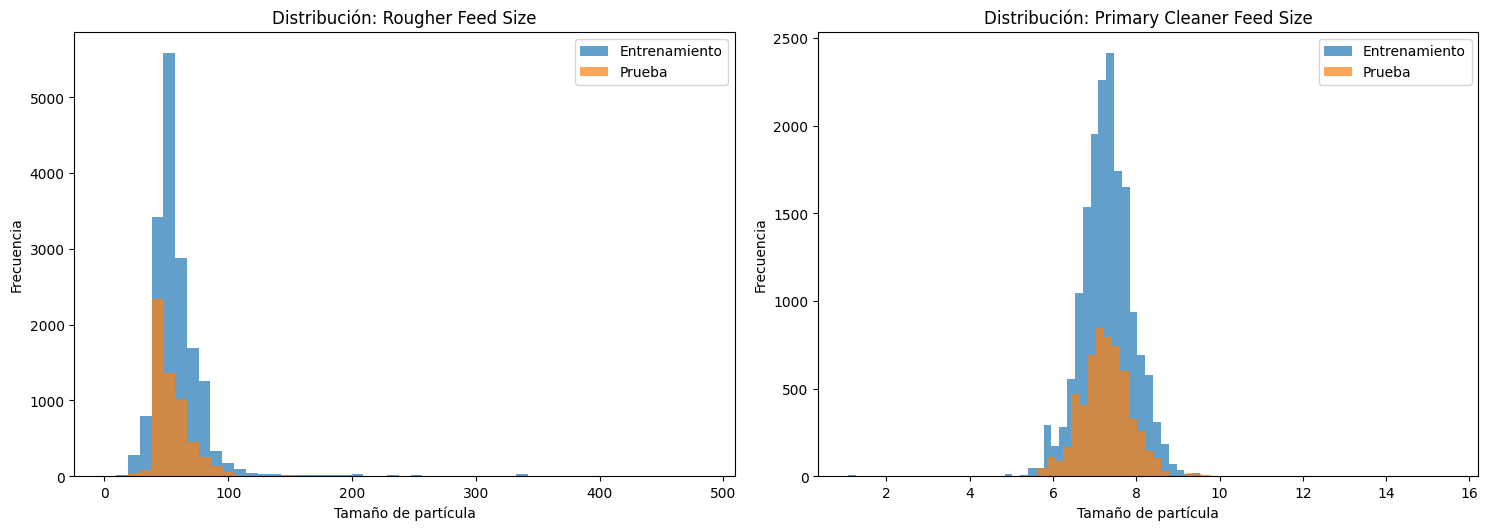

In [24]:
# Crear visualización comparativa
plt.figure(figsize=(15, 10))

# Para rougher feed size
plt.subplot(2, 2, 1)
plt.hist(gold_recovery_train_imputed['rougher.input.feed_size'], alpha=0.7, label='Entrenamiento', bins=50)
plt.hist(gold_recovery_test_imputed['rougher.input.feed_size'], alpha=0.7, label='Prueba', bins=50)
plt.title('Distribución: Rougher Feed Size')
plt.xlabel('Tamaño de partícula')
plt.ylabel('Frecuencia')
plt.legend()

# Para primary cleaner feed size
plt.subplot(2, 2, 2)
plt.hist(gold_recovery_train_imputed['primary_cleaner.input.feed_size'], alpha=0.7, label='Entrenamiento', bins=50)
plt.hist(gold_recovery_test_imputed['primary_cleaner.input.feed_size'], alpha=0.7, label='Prueba', bins=50)
plt.title('Distribución: Primary Cleaner Feed Size')
plt.xlabel('Tamaño de partícula')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.savefig('Images/Distributions.png')
plt.show()

De acuewrdo con el análisis estadístico hecho previamente, se observa que para Rougher feed size la distribución no es normal pero es consistente entre en conjunto de prueba y el de entrenamiento.

Por otro lado, para Primary cleaner feed size, se observa que la distribución es normal en ambos conjuntos, además las medias y las desviaciones estándar son similares para ambos conjuntos (prueba y entrenamiento).

De esta forma no habrá sesgo de datos, el modelo será confiable (haciendo que las predicciones en el conjunto de prueba serán representativas en el rendiemiento real) y se ha validado de forma exitosa la división de datos.

#### 2.3. Considera las concentraciones totales de todas las sustancias en las diferentes etapas: materia prima, concentrado rougher y concentrado final. ¿Observas algún valor anormal en la distribución total? Si es así, ¿merece la pena eliminar esos valores de ambas muestras? Describe los resultados y elimina las anomalías

In [25]:
# Ver todas las columnas para identificar patrones
print("Todas las columnas disponibles:")
for i, col in enumerate(gold_recovery_train.columns):
    print(f"{i}: {col}")

Todas las columnas disponibles:
0: date
1: final.output.concentrate_ag
2: final.output.concentrate_pb
3: final.output.concentrate_sol
4: final.output.concentrate_au
5: final.output.recovery
6: final.output.tail_ag
7: final.output.tail_pb
8: final.output.tail_sol
9: final.output.tail_au
10: primary_cleaner.input.sulfate
11: primary_cleaner.input.depressant
12: primary_cleaner.input.feed_size
13: primary_cleaner.input.xanthate
14: primary_cleaner.output.concentrate_ag
15: primary_cleaner.output.concentrate_pb
16: primary_cleaner.output.concentrate_sol
17: primary_cleaner.output.concentrate_au
18: primary_cleaner.output.tail_ag
19: primary_cleaner.output.tail_pb
20: primary_cleaner.output.tail_sol
21: primary_cleaner.output.tail_au
22: primary_cleaner.state.floatbank8_a_air
23: primary_cleaner.state.floatbank8_a_level
24: primary_cleaner.state.floatbank8_b_air
25: primary_cleaner.state.floatbank8_b_level
26: primary_cleaner.state.floatbank8_c_air
27: primary_cleaner.state.floatbank8_c_lev

In [26]:
# 1. Materia prima (rougher input)
materia_prima_total = (
    gold_recovery_train_imputed['rougher.input.feed_au'] + 
    gold_recovery_train_imputed['rougher.input.feed_ag'] + 
    gold_recovery_train_imputed['rougher.input.feed_pb'] + 
    gold_recovery_train_imputed['rougher.input.feed_sol']
)

# 2. Concentrado rougher  
concentrado_rougher_total = (
    gold_recovery_train_imputed['rougher.output.concentrate_au'] + 
    gold_recovery_train_imputed['rougher.output.concentrate_ag'] + 
    gold_recovery_train_imputed['rougher.output.concentrate_pb'] + 
    gold_recovery_train_imputed['rougher.output.concentrate_sol']
)

# 3. Concentrado final
concentrado_final_total = (
    gold_recovery_train_imputed['final.output.concentrate_au'] + 
    gold_recovery_train_imputed['final.output.concentrate_ag'] + 
    gold_recovery_train_imputed['final.output.concentrate_pb'] + 
    gold_recovery_train_imputed['final.output.concentrate_sol']
)

print('La concentración total en rougher input es:', materia_prima_total)
print()
print('La concentración total en rougher  output concentrate es:', concentrado_rougher_total)
print()
print('La concentración total en final output concentrate es:', concentrado_final_total)

La concentración total en rougher input es: date
2016-01-15 00:00:00    51.680034
2016-01-15 01:00:00    50.659114
2016-01-15 02:00:00    50.609929
2016-01-15 03:00:00    51.061546
2016-01-15 04:00:00    47.859163
                         ...    
2018-08-18 06:59:59    53.415050
2018-08-18 07:59:59    53.696482
2018-08-18 08:59:59    54.589604
2018-08-18 09:59:59    54.027355
2018-08-18 10:59:59    53.535054
Length: 16860, dtype: float64

La concentración total en rougher  output concentrate es: date
2016-01-15 00:00:00    66.424950
2016-01-15 01:00:00    67.012710
2016-01-15 02:00:00    66.103793
2016-01-15 03:00:00    65.752751
2016-01-15 04:00:00    65.908382
                         ...    
2018-08-18 06:59:59    70.781325
2018-08-18 07:59:59    70.539603
2018-08-18 08:59:59    55.376330
2018-08-18 09:59:59    69.201689
2018-08-18 10:59:59    69.544003
Length: 16860, dtype: float64

La concentración total en final output concentrate es: date
2016-01-15 00:00:00    63.644396
2016-01

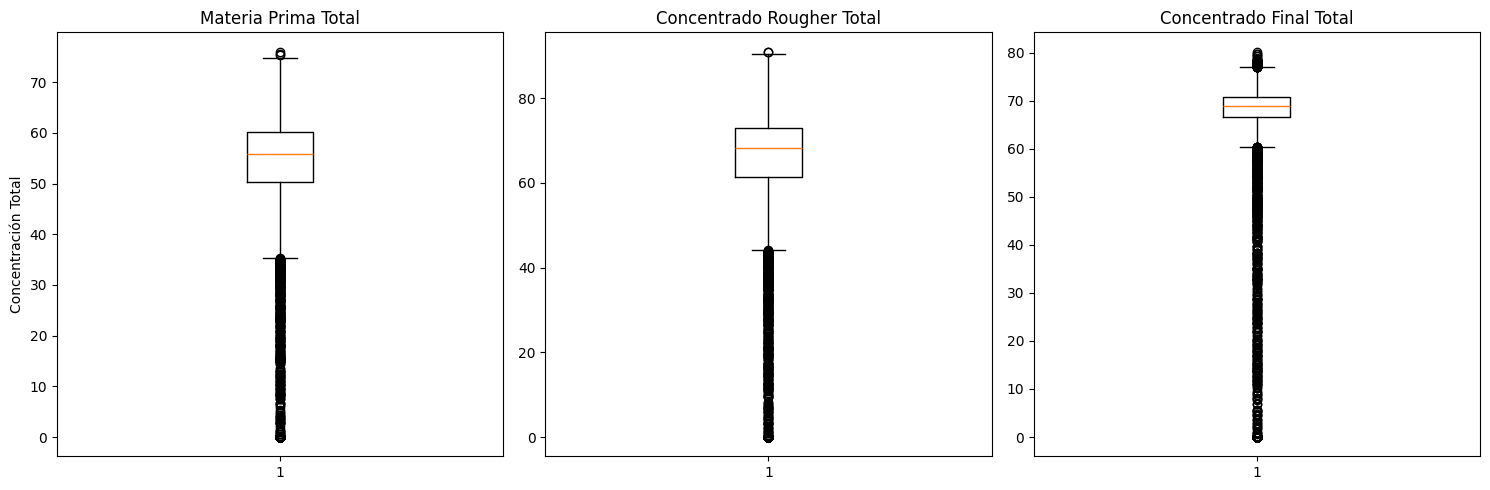

In [28]:
import matplotlib.pyplot as plt

# Crear subplots para comparar las tres etapas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot para cada etapa
axes[0].boxplot(materia_prima_total.dropna())
axes[0].set_title('Materia Prima Total')
axes[0].set_ylabel('Concentración Total')

axes[1].boxplot(concentrado_rougher_total.dropna())
axes[1].set_title('Concentrado Rougher Total')

axes[2].boxplot(concentrado_final_total.dropna())
axes[2].set_title('Concentrado Final Total')

plt.tight_layout()
plt.savefig('Images/Chemical_concentration.png')
plt.show()

In [29]:
# Investigar los valores de 0.0
print("Análisis de valores cero:")
print(f"Materia prima con valor 0: {(materia_prima_total == 0).sum()} casos")
print(f"Concentrado rougher con valor 0: {(concentrado_rougher_total == 0).sum()} casos")
print(f"Concentrado final con valor 0: {(concentrado_final_total == 0).sum()} casos")

Análisis de valores cero:
Materia prima con valor 0: 1213 casos
Concentrado rougher con valor 0: 1547 casos
Concentrado final con valor 0: 1318 casos


In [30]:
# Encontrar registros con concentración total igual a 0
indices_a_eliminar = materia_prima_total[materia_prima_total == 0].index

print(f"Registros a eliminar: {len(indices_a_eliminar)}")
print(f"Índices: {indices_a_eliminar}")

# Eliminar del dataset principal
gold_recovery_train_clean = gold_recovery_train_imputed.drop(indices_a_eliminar)

print(f"Dataset original: {len(gold_recovery_train_imputed)} registros")
print(f"Dataset limpio: {len(gold_recovery_train_clean)} registros")


# Recalcular con datos limpios
materia_prima_total_clean = (
    gold_recovery_train_clean['rougher.input.feed_au'] +
    gold_recovery_train_clean['rougher.input.feed_ag'] +
    gold_recovery_train_clean['rougher.input.feed_pb'] +
    gold_recovery_train_clean['rougher.input.feed_sol']
)

concentrado_rougher_total_clean = (
    gold_recovery_train_clean['rougher.output.concentrate_au'] +
    gold_recovery_train_clean['rougher.output.concentrate_ag'] +
    gold_recovery_train_clean['rougher.output.concentrate_pb'] +
    gold_recovery_train_clean['rougher.output.concentrate_sol']
)

concentrado_final_total_clean = (
    gold_recovery_train_clean['final.output.concentrate_au'] +
    gold_recovery_train_clean['final.output.concentrate_ag'] +
    gold_recovery_train_clean['final.output.concentrate_pb'] +
    gold_recovery_train_clean['final.output.concentrate_sol']
)

Registros a eliminar: 1213
Índices: DatetimeIndex(['2016-01-19 03:00:00', '2016-01-19 04:00:00',
               '2016-01-19 05:00:00', '2016-01-19 06:00:00',
               '2016-01-19 07:00:00', '2016-01-19 08:00:00',
               '2016-01-19 09:00:00', '2016-01-19 10:00:00',
               '2016-01-19 11:00:00', '2016-01-19 12:00:00',
               ...
               '2018-01-29 22:59:59', '2018-01-29 23:59:59',
               '2018-01-30 00:59:59', '2018-01-30 01:59:59',
               '2018-01-30 02:59:59', '2018-01-30 03:59:59',
               '2018-01-30 04:59:59', '2018-01-30 05:59:59',
               '2018-01-30 06:59:59', '2018-01-30 07:59:59'],
              dtype='datetime64[us]', name='date', length=1213, freq=None)
Dataset original: 16860 registros
Dataset limpio: 15647 registros


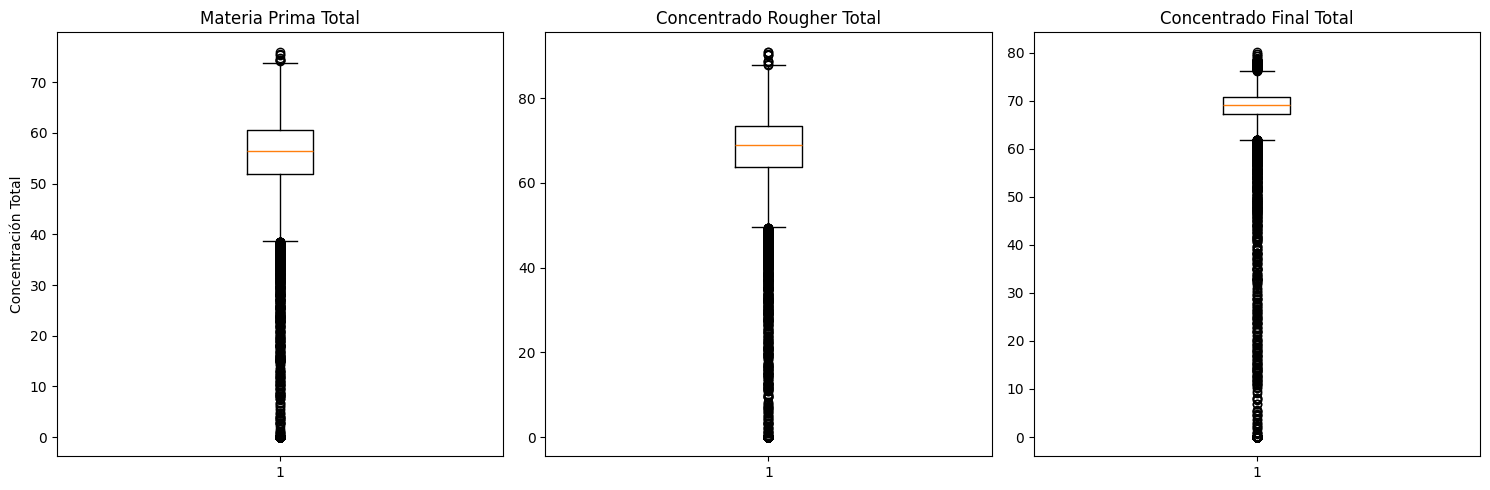

In [31]:
#Visualizar de nuevo los datos con datos limpios

# Crear subplots para comparar las tres etapas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot para cada etapa
axes[0].boxplot(materia_prima_total_clean.dropna())
axes[0].set_title('Materia Prima Total')
axes[0].set_ylabel('Concentración Total')

axes[1].boxplot(concentrado_rougher_total_clean.dropna())
axes[1].set_title('Concentrado Rougher Total')

axes[2].boxplot(concentrado_final_total_clean.dropna())
axes[2].set_title('Concentrado Final Total')

plt.tight_layout()
plt.show()

### Construye el modelo

3.1 Escribre una función para calcular el valor final de sMAPE


In [32]:
# Analizar correlaciones entre variables clave
correlation_matrix = gold_recovery_train_clean[['rougher.input.feed_au', 
                                               'rougher.output.concentrate_au',
                                               'final.output.concentrate_au',
                                               'final.output.recovery']].corr()

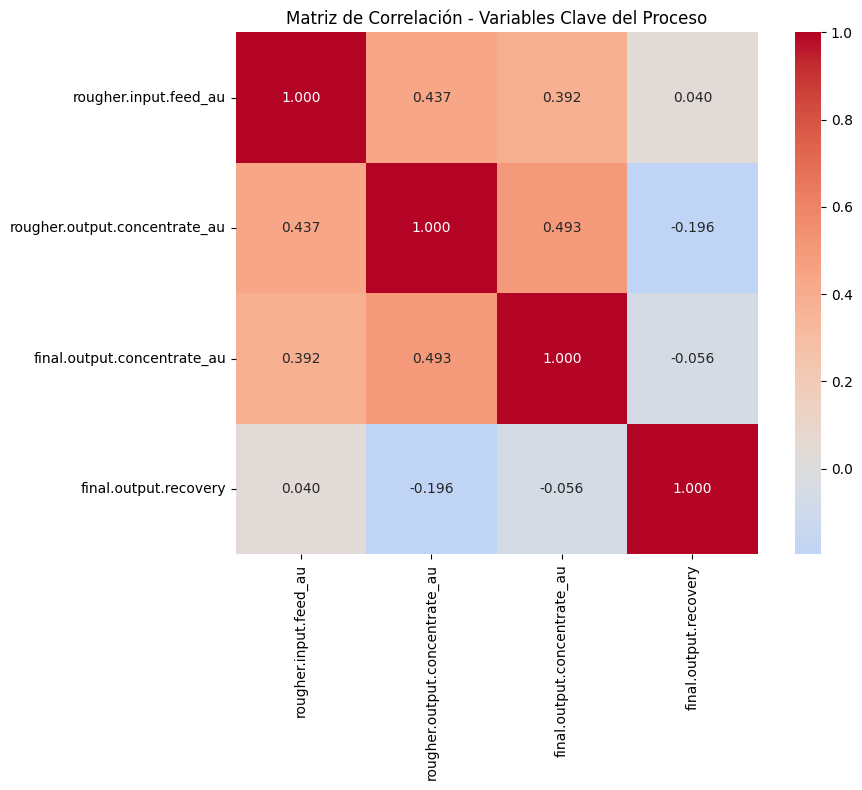

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Matriz de Correlación - Variables Clave del Proceso')
plt.tight_layout()
plt.show()

La matriz de correlación muestra que la cantidad de oro que entra al proceso sí tiene relación con la cantidad de oro que se obtiene en los concentrados, tanto en la etapa rougher como en la final, aunque esa relación no es perfecta. También se observa que el concentrado que se obtiene en la etapa rougher influye de forma clara en el concentrado final, lo cual tiene sentido porque el proceso es continuo y una buena etapa intermedia ayuda al resultado final. En cambio, la recuperación final casi no está relacionada con estas variables, lo que indica que depende de otros factores del proceso y no solo de la cantidad de oro o del concentrado. En general, esto sugiere que el comportamiento del sistema es más complejo y no se puede explicar con una sola variable, por lo que es razonable usar modelos más flexibles para hacer predicciones.

In [34]:
#Calcular el valor final de sMAPE para rougher.output.recovery
import numpy as np

def smape(y_true, y_pred):
    """
    Calcula el sMAPE (Symmetric Mean Absolute Percentage Error)
    """
    return np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

def final_smape(y_true_rougher, y_pred_rougher, y_true_final, y_pred_final):
    """
    Calcula el sMAPE final combinando ambas predicciones
    """
    smape_rougher = smape(y_true_rougher, y_pred_rougher)
    smape_final = smape(y_true_final, y_pred_final)
    return 0.25 * smape_rougher + 0.75 * smape_final

3.2. Entrena diferentes modelos. Evalúalos aplicando la validación cruzada. Elige el mejor modelo y pruébalo utilizando la muestra de prueba

In [35]:
#Definir las variables objetivo

# rougher.output.recovery será la y_true_rougher
y_true_rougher = gold_recovery_train_clean['rougher.output.recovery']

# final.output.recovery será la y_true_final
y_true_final = gold_recovery_train_clean['final.output.recovery']

In [36]:
# Crear el DF features
features = gold_recovery_train_clean.copy()

# Ahora sí puedes eliminar las columnas
columns_to_drop = ['rougher.output.recovery', 'final.output.recovery']
target_columns = [col for col in features.columns if 'output' in col and ('recovery' in col or 'concentrate' in col or 'tail' in col)]
features = features.drop(columns_to_drop + target_columns, axis=1)

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Modelos a probar
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)
}

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer
import numpy as np

# Configurar la validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Crear scorer personalizado para sMAPE
def smape_scorer(y_true, y_pred):
    return smape(y_true, y_pred)

smape_scorer_sklearn = make_scorer(smape_scorer, greater_is_better=False)

# Diccionario para almacenar resultados
results = {}

for model_name, model in models.items():
    print(f"\n Evaluando {model_name}:")
    
    # Validación cruzada para rougher recovery
    scores_rougher = cross_val_score(
        model, features, y_true_rougher, 
        cv=kf, scoring=smape_scorer_sklearn, n_jobs=-1
    )
    
    # Validación cruzada para final recovery  
    scores_final = cross_val_score(
        model, features, y_true_final,
        cv=kf, scoring=smape_scorer_sklearn, n_jobs=-1
    )
    
    # Convertir a valores positivos (porque make_scorer usa greater_is_better=False)
    scores_rougher = -scores_rougher
    scores_final = -scores_final
    
    # Calcular sMAPE final combinado para cada fold
    final_scores = 0.25 * scores_rougher + 0.75 * scores_final
    
    # Almacenar resultados
    results[model_name] = {
        'rougher_smape': scores_rougher,
        'final_smape': scores_final,
        'combined_smape': final_scores,
        'mean_combined': final_scores.mean(),
        'std_combined': final_scores.std()
    }
    
    # Mostrar resultados
    print(f"   Rougher sMAPE: {scores_rougher.mean():.3f} (±{scores_rougher.std():.3f})")
    print(f"   Final sMAPE:   {scores_final.mean():.3f} (±{scores_final.std():.3f})")
    print(f"   sMAPE Combinado: {final_scores.mean():.3f} (±{final_scores.std():.3f})")

print()
print(" RESUMEN DE RESULTADOS:")
print()

# Encontrar el mejor modelo
best_model = min(results.keys(), key=lambda x: results[x]['mean_combined'])
print(f" Mejor modelo: {best_model}")
print(f"   sMAPE combinado: {results[best_model]['mean_combined']:.3f}")


 Evaluando LinearRegression:
   Rougher sMAPE: 11.298 (±0.265)
   Final sMAPE:   11.839 (±0.336)
   sMAPE Combinado: 11.704 (±0.280)

 Evaluando RandomForest:
   Rougher sMAPE: 8.295 (±0.302)
   Final sMAPE:   8.023 (±0.413)
   sMAPE Combinado: 8.091 (±0.319)

 RESUMEN DE RESULTADOS:

 Mejor modelo: RandomForest
   sMAPE combinado: 8.091


De acuerdo con los modelos evaluados, y con el sMAPE, se elige usar el RandomForest debido a que obtuvo un valor más pequeño en el sMAPE. Esto indica que en promedio, las predicciones se desvían un 8.09% del valor real en comparación del 11.70% obtenido con la LinearRegression.

In [38]:
# Entrenar el modelo final con todos los datos de entrenamiento
final_model_rougher = RandomForestRegressor(n_estimators=100, random_state=42)
final_model_final = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar para rougher recovery
final_model_rougher.fit(features, y_true_rougher)

# Entrenar para final recovery  
final_model_final.fit(features, y_true_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Se observó que al probar el modelo con el conjunto de prueba arrojó un error debido a que el modelo se entrenó con 56 columnas, sin embargo, el conjunto de prueba solo tiene 54 columnas

In [46]:
# Crear test_features a partir del conjunto de prueba
test_features = gold_recovery_test_imputed.copy()
# Eliminar las mismas columnas que eliminaste en el conjunto de entrenamiento
# (aunque algunas ya no existen en test)
test_features = test_features.drop(['date'], axis=1, errors='ignore')


# Revisar qué columnas faltan en features vs test_features
features_final = set(features.columns)
test_features_final = set(test_features.columns)
missing_in_test_final = features_final - test_features_final

print(f"Columnas que están en train pero NO en test: {len(missing_in_test_final)}")
print("Columnas faltantes:")
print(list(missing_in_test_final)[:])

Columnas que están en train pero NO en test: 4
Columnas faltantes:
['rougher.calculation.au_pb_ratio', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.floatbank10_sulfate_to_au_feed']


In [47]:
# Debido a que estas cuatro columnas se encuentran en el conjunto de entrenamiento pero no en el de test_features, se decició eliminar para poder continuar con el proyecto: 
columns_to_remove = [
    'rougher.calculation.au_pb_ratio', 
    'rougher.calculation.sulfate_to_au_concentrate', 
    'rougher.calculation.floatbank10_sulfate_to_au_feed', 
    'rougher.calculation.floatbank11_sulfate_to_au_feed'
]

In [48]:
# Actualizar features eliminando las columnas que no están en test
features_updated = features.drop(columns_to_remove, axis=1)

print(f"Features originales: {features.shape[1]} columnas")
print(f"Features actualizadas: {features_updated.shape[1]} columnas")
print(f"Test features: {test_features.shape[1]} columnas")

Features originales: 56 columnas
Features actualizadas: 52 columnas
Test features: 52 columnas


In [49]:
# Re-entrenar los modelos con las características actualizadas
final_model_rougher_updated = RandomForestRegressor(n_estimators=100, random_state=42)
final_model_final_updated = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar para rougher recovery
final_model_rougher_updated.fit(features_updated, y_true_rougher)

# Entrenar para final recovery
final_model_final_updated.fit(features_updated, y_true_final)

print("Modelos re-entrenados exitosamente")

Modelos re-entrenados exitosamente


In [50]:
# Hacer predicciones con los modelos actualizados
pred_rougher = final_model_rougher_updated.predict(test_features)
pred_final = final_model_final_updated.predict(test_features)

In [51]:
# Estadísticas descriptivas de las predicciones:

print(f"Predicciones rougher recovery:")
print(f"  - Mínimo: {pred_rougher.min():.2f}%")
print(f"  - Máximo: {pred_rougher.max():.2f}%")
print(f"  - Promedio: {pred_rougher.mean():.2f}%")
print(f"  - Desviación estándar: {pred_rougher.std():.2f}%")

print(f"\nPredicciones final recovery:")
print(f"  - Mínimo: {pred_final.min():.2f}%")
print(f"  - Máximo: {pred_final.max():.2f}%")
print(f"  - Promedio: {pred_final.mean():.2f}%")
print(f"  - Desviación estándar: {pred_final.std():.2f}%")

Predicciones rougher recovery:
  - Mínimo: 26.46%
  - Máximo: 93.08%
  - Promedio: 78.33%
  - Desviación estándar: 9.93%

Predicciones final recovery:
  - Mínimo: 13.87%
  - Máximo: 99.80%
  - Promedio: 67.11%
  - Desviación estándar: 9.24%


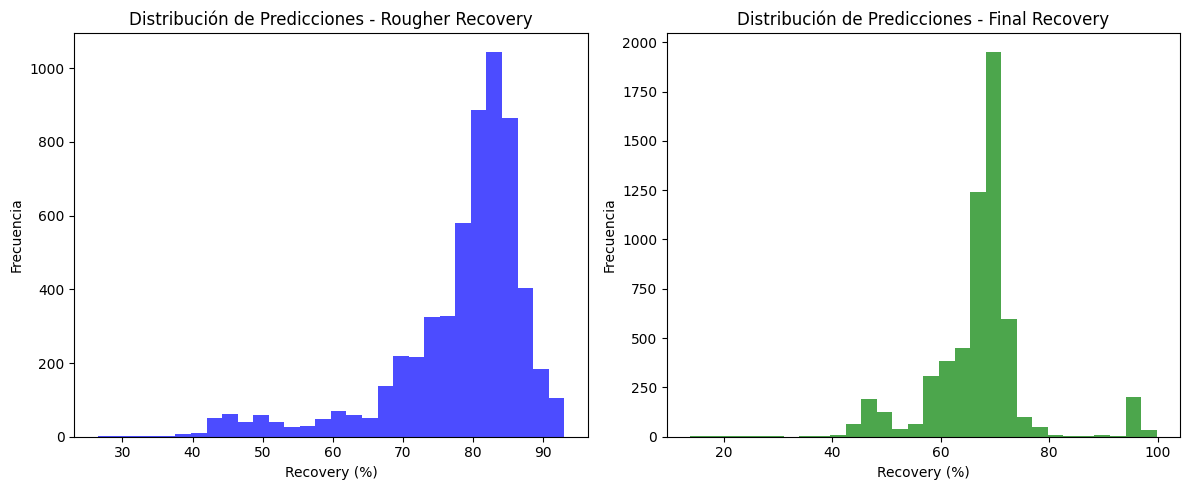

In [52]:
#Visualizar las distribuciones
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(pred_rougher, bins=30, alpha=0.7, color='blue')
plt.title('Distribución de Predicciones - Rougher Recovery')
plt.xlabel('Recovery (%)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(pred_final, bins=30, alpha=0.7, color='green')
plt.title('Distribución de Predicciones - Final Recovery')
plt.xlabel('Recovery (%)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [53]:
# Comparar predicciones con datos de entrenamiento

print("ROUGHER RECOVERY:")
print("Entrenamiento:")
print(f"  - Promedio: {y_true_rougher.mean():.2f}%")
print(f"  - Desviación estándar: {y_true_rougher.std():.2f}%")
print(f"  - Rango: {y_true_rougher.min():.2f}% - {y_true_rougher.max():.2f}%")

print("Predicciones:")
print(f"  - Promedio: {pred_rougher.mean():.2f}%")
print(f"  - Desviación estándar: {pred_rougher.std():.2f}%")
print(f"  - Rango: {pred_rougher.min():.2f}% - {pred_rougher.max():.2f}%")

print("\nFINAL RECOVERY:")
print("Entrenamiento:")
print(f"  - Promedio: {y_true_final.mean():.2f}%")
print(f"  - Desviación estándar: {y_true_final.std():.2f}%")
print(f"  - Rango: {y_true_final.min():.2f}% - {y_true_final.max():.2f}%")

print("Predicciones:")
print(f"  - Promedio: {pred_final.mean():.2f}%")
print(f"  - Desviación estándar: {pred_final.std():.2f}%")
print(f"  - Rango: {pred_final.min():.2f}% - {pred_final.max():.2f}%")

ROUGHER RECOVERY:
Entrenamiento:
  - Promedio: 82.06%
  - Desviación estándar: 15.43%
  - Rango: 0.00% - 100.00%
Predicciones:
  - Promedio: 78.33%
  - Desviación estándar: 9.93%
  - Rango: 26.46% - 93.08%

FINAL RECOVERY:
Entrenamiento:
  - Promedio: 66.88%
  - Desviación estándar: 12.94%
  - Rango: 0.00% - 100.00%
Predicciones:
  - Promedio: 67.11%
  - Desviación estándar: 9.24%
  - Rango: 13.87% - 99.80%


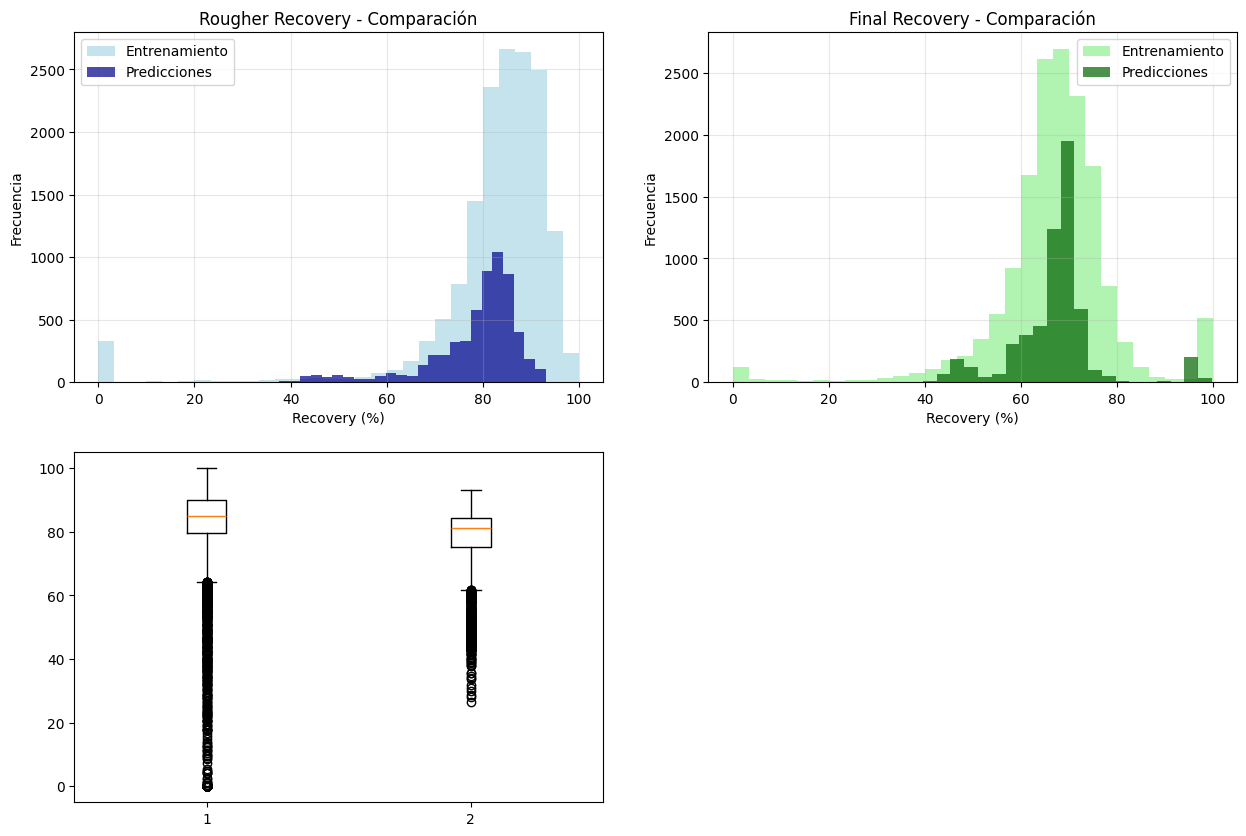

In [55]:
# Crear gráfico comparativo más detallado
plt.figure(figsize=(15, 10))

# Rougher Recovery
plt.subplot(2, 2, 1)
plt.hist(y_true_rougher, bins=30, alpha=0.7, label='Entrenamiento', color='lightblue')
plt.hist(pred_rougher, bins=30, alpha=0.7, label='Predicciones', color='darkblue')
plt.title('Rougher Recovery - Comparación')
plt.xlabel('Recovery (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

# Final Recovery
plt.subplot(2, 2, 2)
plt.hist(y_true_final, bins=30, alpha=0.7, label='Entrenamiento', color='lightgreen')
plt.hist(pred_final, bins=30, alpha=0.7, label='Predicciones', color='darkgreen')
plt.title('Final Recovery - Comparación')
plt.xlabel('Recovery (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plots
plt.subplot(2, 2, 3)
plt.boxplot([y_true_rougher, pred_rougher])
plt.savefig('Images/Rougher_and_final_recovery.png')
plt.show()

Conclusiones

El modelo RandomForest fue seleccionado como la mejor opción del proyecto, ya que alcanzó un sMAPE combinado de 8.09%, lo que representa una excelente precisión y una mejora de 3.61 puntos porcentuales frente a la regresión lineal. Las predicciones de rougher recovery y final recovery se mantienen dentro de rangos realistas para el proceso industrial y presentan promedios muy consistentes con los datos de entrenamiento, lo que indica una buena capacidad de generalización. Además, la variabilidad de las predicciones es menor que la observada en el conjunto de entrenamiento, un comportamiento esperado y positivo en modelos de machine learning, ya que tienden a ser más conservadores.

En el contexto industrial de recuperación de oro, este nivel de precisión es suficiente como herramienta de apoyo para la toma de decisiones operativas, especialmente para anticipar tendencias y detectar posibles desviaciones del proceso. Sin embargo, el modelo no debe utilizarse como el único criterio de decisión. Es importante considerar factores adicionales como el impacto económico del error, la estabilidad del modelo en el tiempo ante cambios en el mineral o en las condiciones operativas, así como la incorporación de variables del proceso más detalladas. Finalmente, las validaciones realizadas confirman la solidez del enfoque, con distribuciones coherentes entre los conjuntos de entrenamiento y prueba, una correcta eliminación de anomalías y un manejo adecuado de valores faltantes, lo que respalda su uso como una herramienta confiable dentro de un sistema de decisión más amplio.